# Floodscan validation

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [246]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.datasources import floodscan, codab, glofas
from src.constants import NDJAMENA2
from src.raster import upsample_dataarray

In [158]:
# June 1
SEASON_START_DAYOFYEAR = 152
# Oct 1
SEASON_MID_DAYOFYEAR = 274
# Dec 1
SEASON_END_DAYOFYEAR = 335

In [159]:
floodscan.process_ndjamena_daily_floodscan()

In [160]:
fs_mean = floodscan.load_ndjamena_daily_floodscan()

<Axes: xlabel='time'>

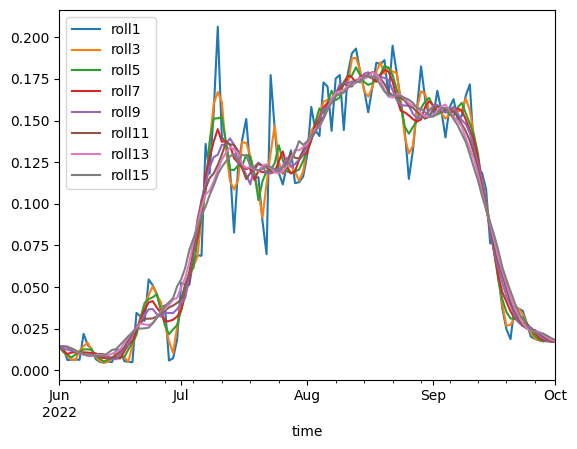

In [161]:
fs_mean[
    (fs_mean["time"] >= "2022-06-01") & (fs_mean["time"] <= "2022-10-01")
].set_index("time")[[x for x in fs_mean.columns if "roll" in x]].plot()

In [207]:
rea = glofas.load_reanalysis()

In [208]:
compare = rea.merge(fs_mean)
compare["dayofyear"] = compare["time"].dt.dayofyear
compare = compare[
    (compare["dayofyear"] >= SEASON_START_DAYOFYEAR)
    # (compare["dayofyear"] >= SEASON_MID_DAYOFYEAR)
    & (compare["dayofyear"] <= SEASON_END_DAYOFYEAR)
]
compare["roll7_late"] = compare.apply(
    lambda row: (
        row["roll7"] if row["dayofyear"] >= SEASON_MID_DAYOFYEAR else np.nan
    ),
    axis=1,
)

In [209]:
compare.corr()["dis24"]

time         -0.154451
dis24         1.000000
SFED_AREA    -0.115386
roll1        -0.115386
roll3        -0.117965
roll5        -0.119395
roll7        -0.120239
roll9        -0.120770
roll11       -0.121124
roll13       -0.121296
roll15       -0.121252
dayofyear     0.393017
roll7_late    0.012590
Name: dis24, dtype: float64

In [210]:
compare[compare["time"] == "2022-10-01"]

,time,dis24,SFED_AREA,roll1,roll3,roll5,roll7,roll9,roll11,roll13,roll15,dayofyear,roll7_late
7213,2022-10-01,5349.9453,0.016954,0.016954,0.017398,0.017275,0.017022,0.017089,0.01728,0.0175,0.018159,274,0.017022


In [211]:
peaks = compare.groupby(compare["time"].dt.year).max().reset_index(drop=True)
peaks["year"] = peaks["time"].dt.year

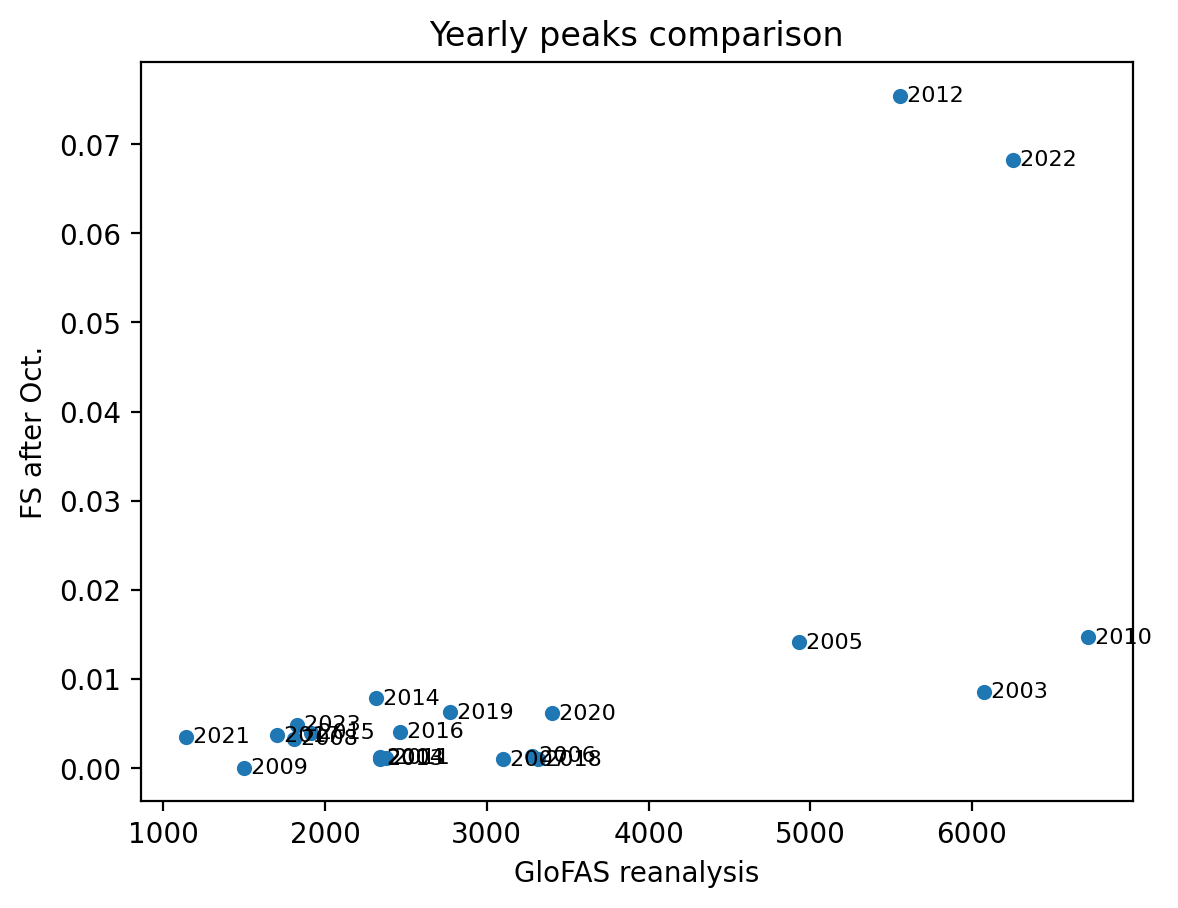

In [236]:
fs_col = "roll7_late"

fig, ax = plt.subplots(dpi=200)
peaks.plot.scatter(x="dis24", y=fs_col, ax=ax)
for year, row in peaks.set_index("year").iterrows():
    flip_years = []
    ha = "right" if year in flip_years else "left"
    ax.annotate(
        f" {year} ",
        (row["dis24"], row[fs_col]),
        color="k",
        fontsize=8,
        va="center",
        ha=ha,
    )
    ax.set_ylabel("FS after Oct.")
    ax.set_xlabel("GloFAS reanalysis")
    ax.set_title("Yearly peaks comparison")

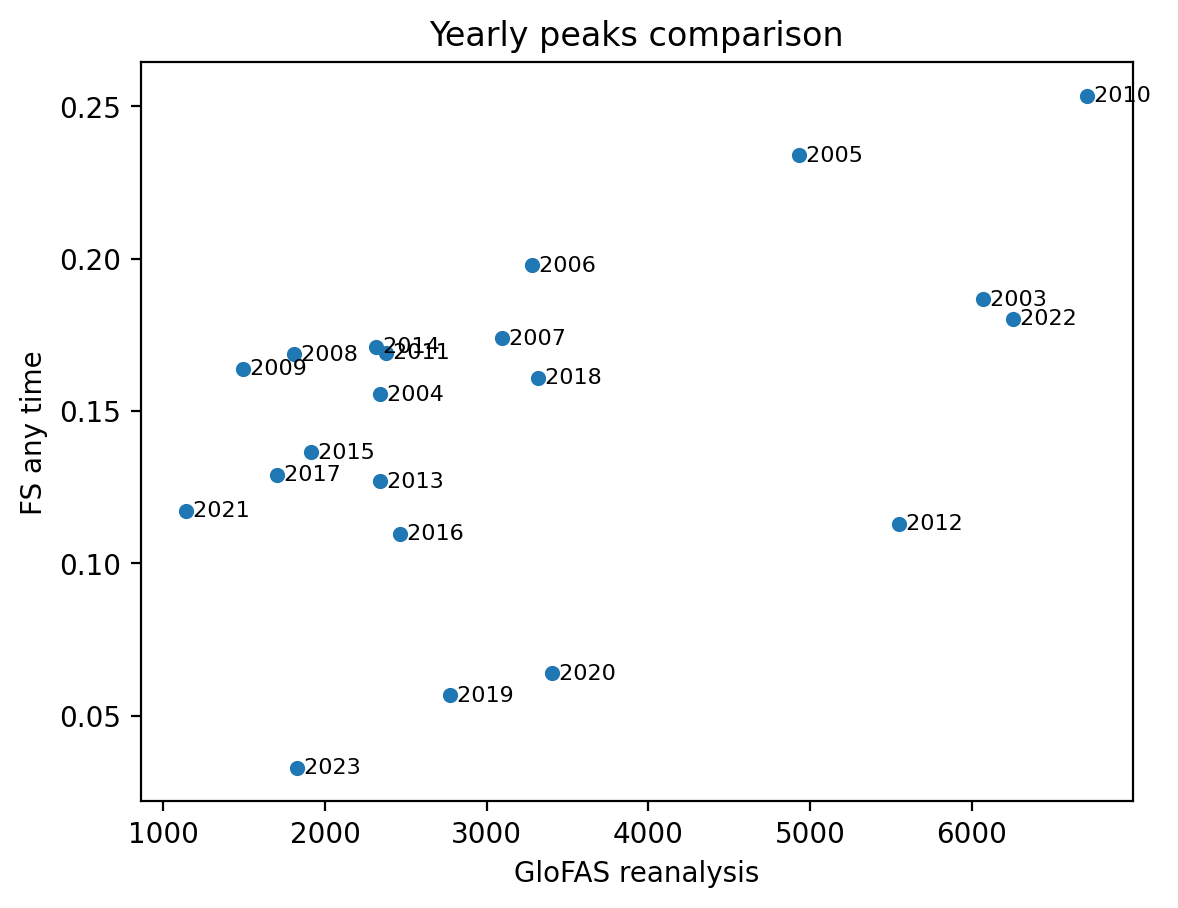

In [237]:
fs_col = "roll7"

fig, ax = plt.subplots(dpi=200)
peaks.plot.scatter(x="dis24", y=fs_col, ax=ax)
for year, row in peaks.set_index("year").iterrows():
    flip_years = []
    ha = "right" if year in flip_years else "left"
    ax.annotate(
        f" {year} ",
        (row["dis24"], row[fs_col]),
        color="k",
        fontsize=8,
        va="center",
        ha=ha,
    )
    ax.set_ylabel("FS any time")
    ax.set_xlabel("GloFAS reanalysis")
    ax.set_title("Yearly peaks comparison")

In [218]:
21 / 5

4.2

In [233]:
def highlight_true(val):
    if isinstance(val, bool) and val is True:
        return "background-color: crimson"
    return ""


df_plot = peaks.copy()
df_plot["rank"] = df_plot["dis24"].rank(ascending=False).astype(int)

cols = ["dis24", "roll7", "roll7_late"]

target_rp = 5

for x in cols:
    thresh = df_plot[x].quantile(1 - 1 / target_rp)
    df_plot[f"{x}_trig"] = df_plot[x] > thresh

df_plot = df_plot.sort_values("dis24", ascending=False)
df_plot = df_plot.rename(
    columns={
        "dis24_trig": "GF reanalysis",
        "roll7_trig": "FS",
        "roll7_late_trig": "FS (after Oct)",
    }
)
df_plot.set_index("rank")[
    ["year", "GF reanalysis", "FS", "FS (after Oct)"]
].style.map(highlight_true)

,year,GF reanalysis,FS,FS (after Oct)
rank,,,,
1,2010,True,True,True
2,2022,True,False,True
3,2003,True,True,False
4,2012,True,False,True
5,2005,False,True,True
6,2020,False,False,False
7,2018,False,False,False
8,2006,False,True,False
9,2007,False,False,False


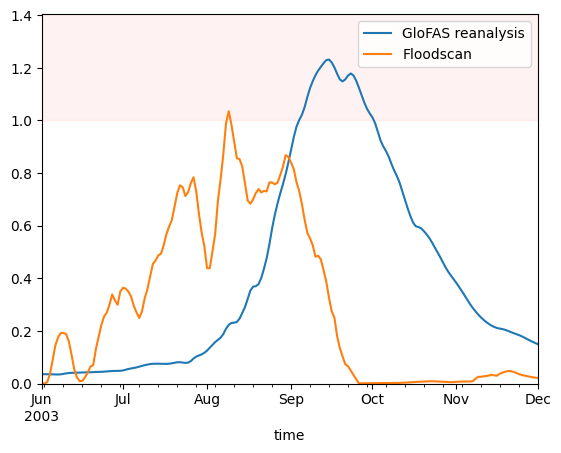

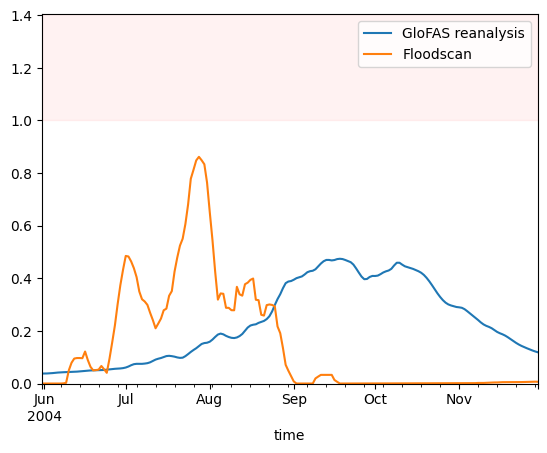

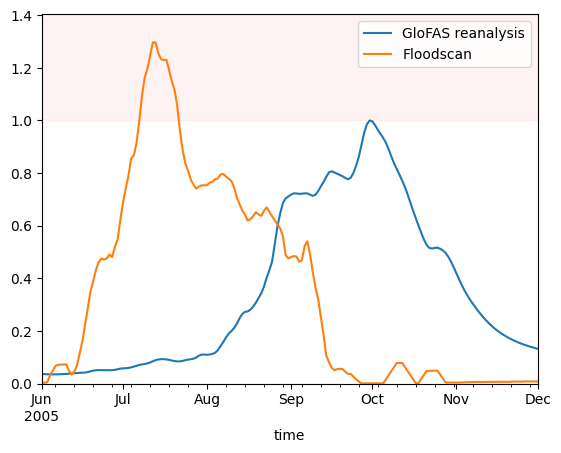

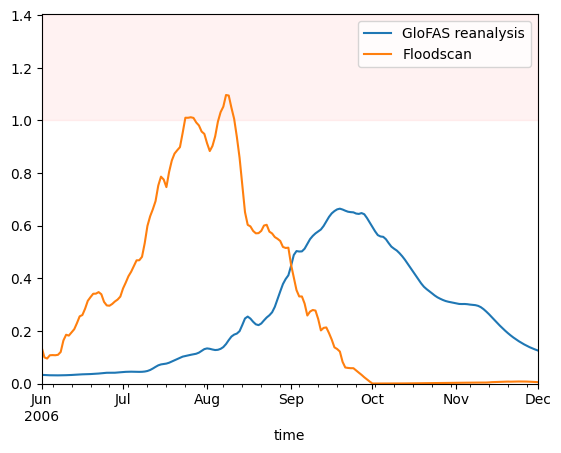

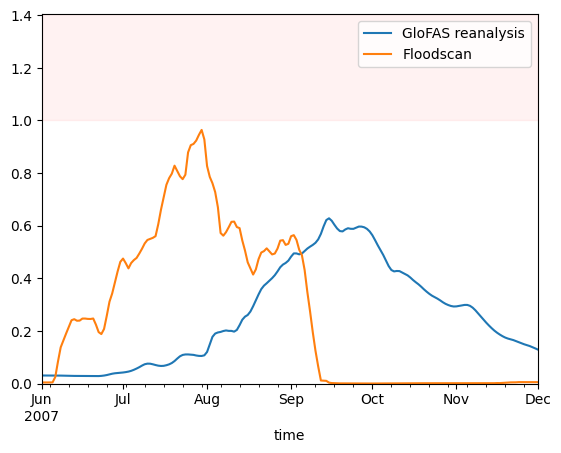

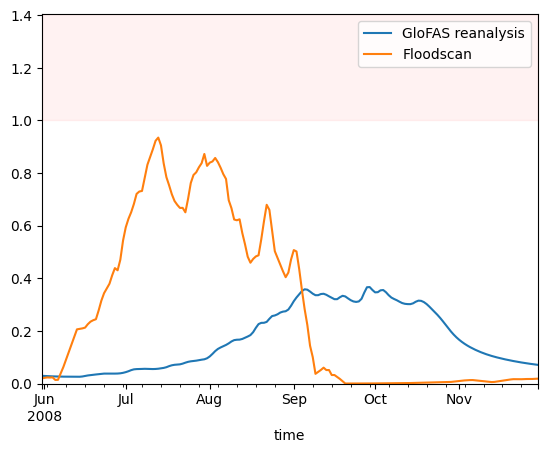

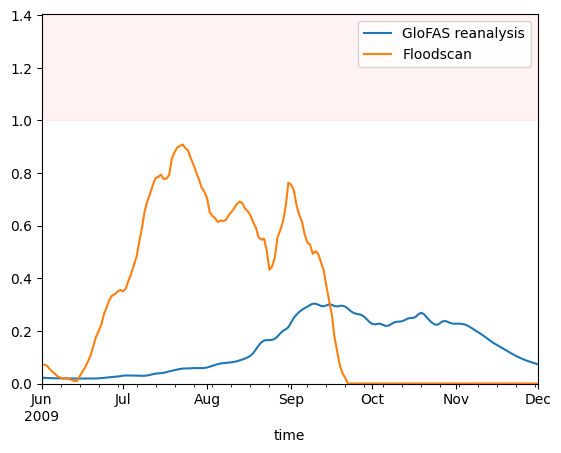

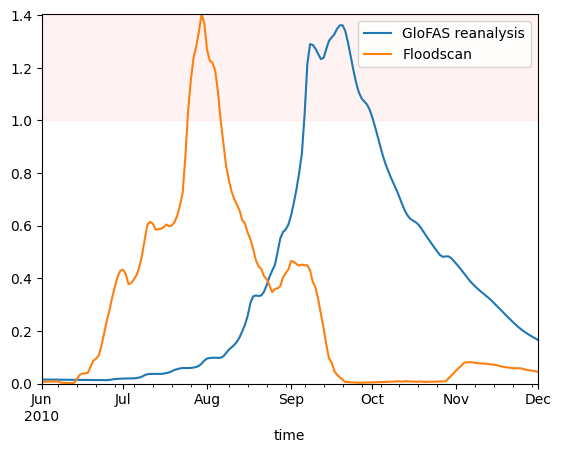

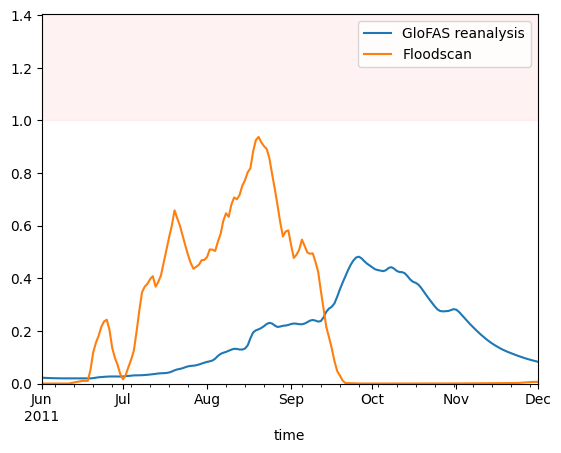

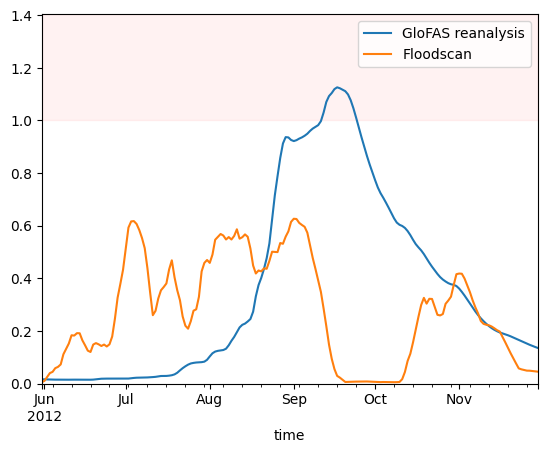

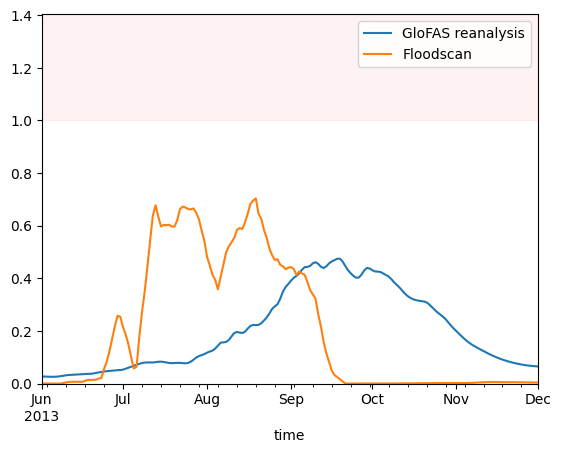

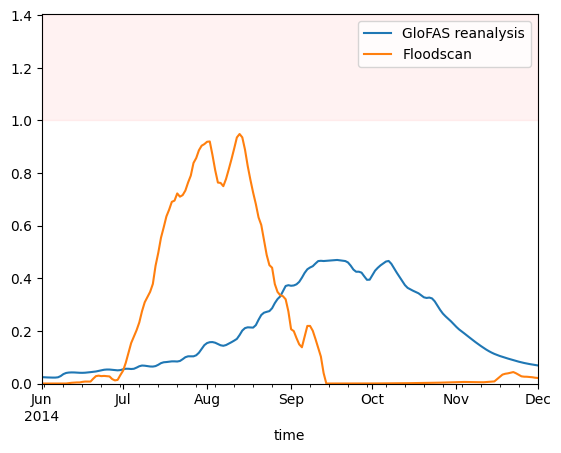

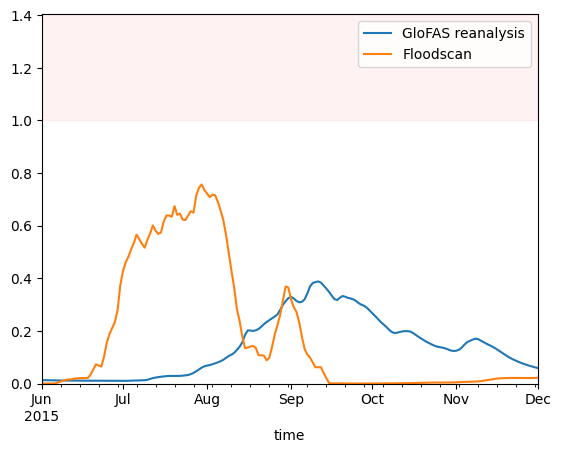

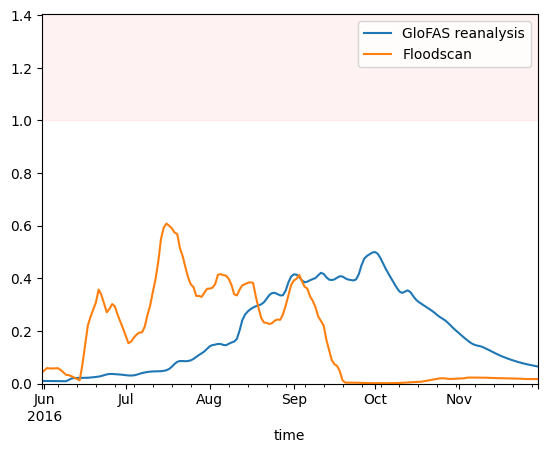

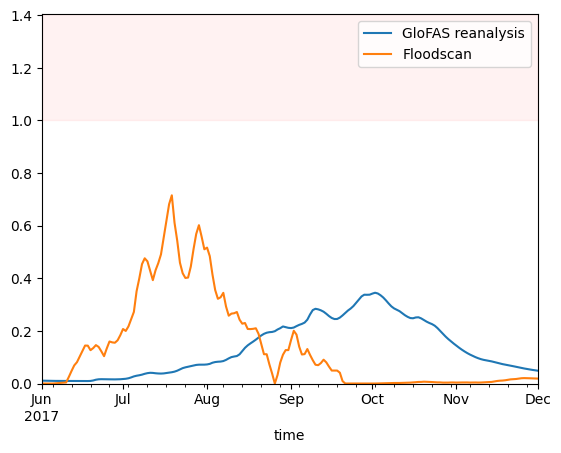

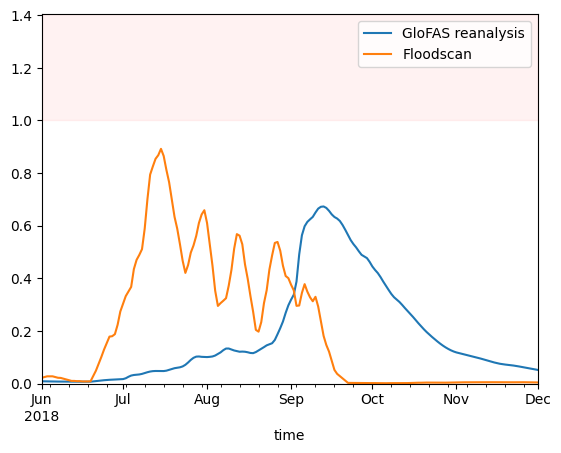

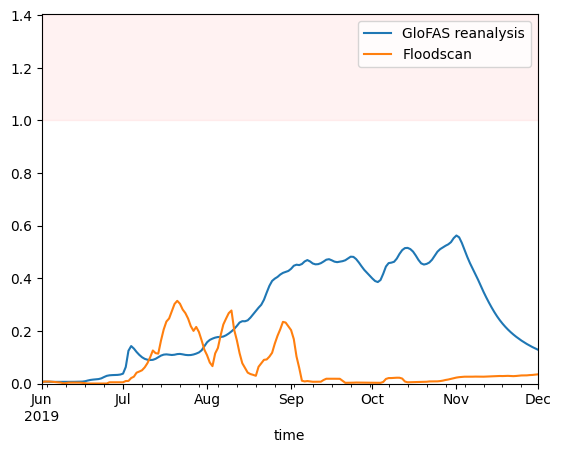

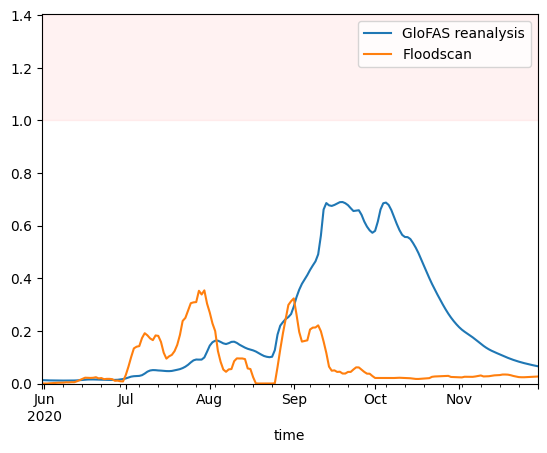

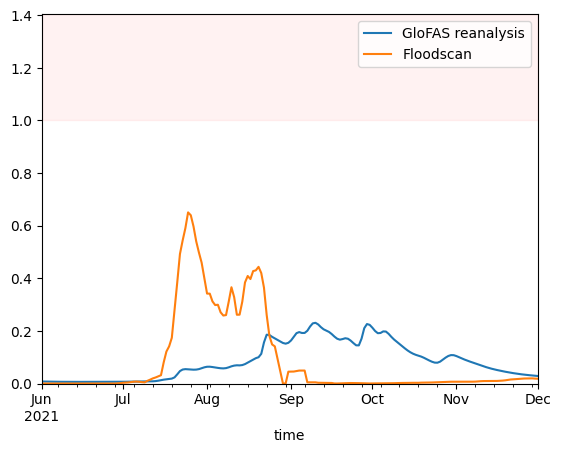

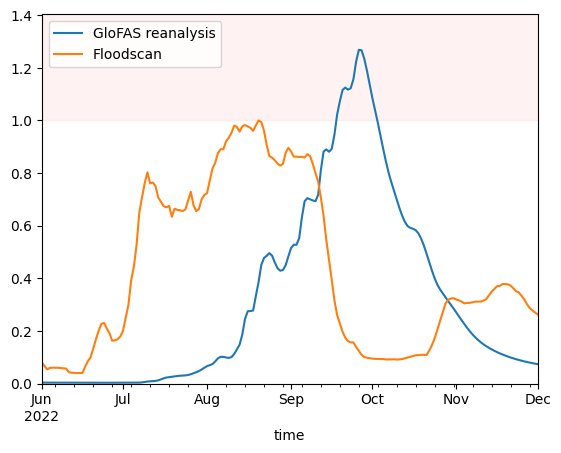

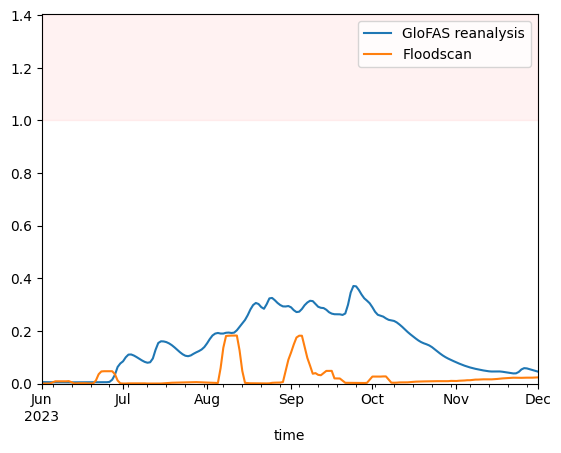

In [228]:
fs_col = "roll7"

df_plot = compare.copy()
for x in ["dis24", fs_col]:
    thresh = peaks[x].quantile(1 - 1 / target_rp)
    df_plot[f"{x}_norm"] = df_plot[x] / thresh

max_y = df_plot[[f"{fs_col}_norm", "dis24_norm"]].max().max()

for year, group in df_plot.groupby(compare["time"].dt.year):
    fig, ax = plt.subplots()
    group.plot(x="time", y=["dis24_norm", f"{fs_col}_norm"], ax=ax)
    ax.set_ylim(0, max_y)
    ax.axhspan(
        1,
        max_y,
        color="red",
        alpha=0.05,
    )
    ax.legend(["GloFAS reanalysis", "Floodscan"])
    plt.show()
    plt.close()

In [140]:
fs_q

0.16978834285622552

In [263]:
seasonal = (
    compare.groupby("dayofyear")[["roll7", "dis24"]].mean().reset_index()
)

In [264]:
pd.to_datetime("2000-01-01")

Timestamp('2000-01-01 00:00:00')

In [265]:
seasonal["eff_date"] = pd.to_datetime(
    seasonal["dayofyear"], format="%j", errors="coerce"
).apply(lambda x: x.replace(year=2000))

Text(0.5, 1.0, "Seasonal average flooded fraction of N'Djamena (2003-2023)")

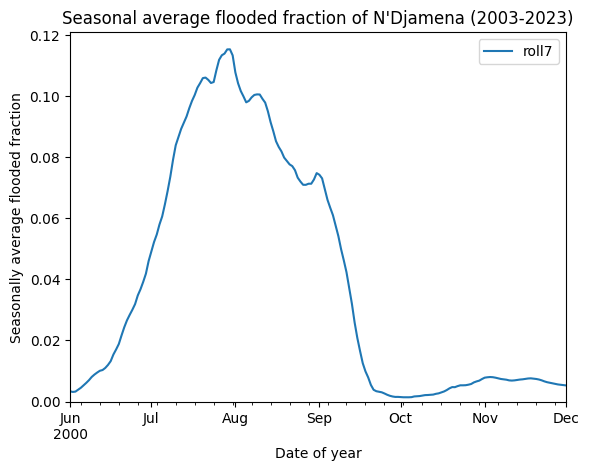

In [266]:
ax = seasonal.plot(x="eff_date", y="roll7")
ax.set_ylim(bottom=0)
ax.set_ylabel("Seasonally average flooded fraction")
ax.set_xlabel("Date of year")
ax.set_title("Seasonal average flooded fraction of N'Djamena (2003-2023)")

Text(0.5, 1.0, "Seasonal average flooded fraction of N'Djamena (2003-2023)")

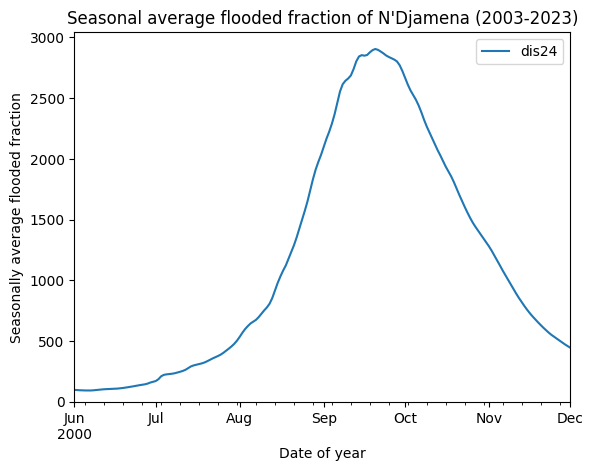

In [267]:
ax = seasonal.plot(x="eff_date", y="dis24")
ax.set_ylim(bottom=0)
ax.set_ylabel("Seasonally average flooded fraction")
ax.set_xlabel("Date of year")
ax.set_title("Seasonal average flooded fraction of N'Djamena (2003-2023)")

<Axes: xlabel='dis24', ylabel='roll7'>

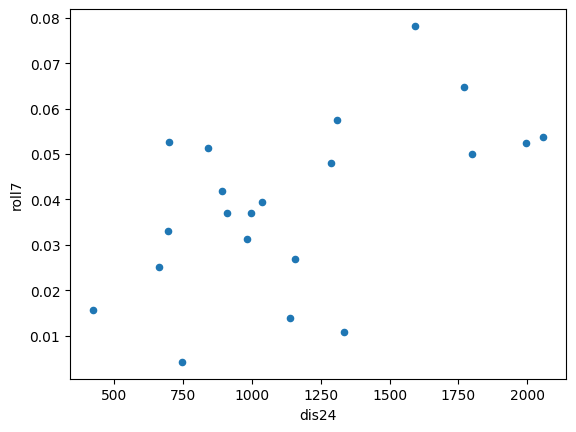

In [123]:
means = compare.groupby(compare["time"].dt.year).mean().reset_index(drop=True)
means["year"] = means["time"].dt.year
means.plot.scatter(x="dis24", y="roll7")